In [ ]:
import os
import numpy as np
import coda
import matplotlib.pyplot as plt

# from hapi import *

HAPI version: 1.2.2.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

### DATA

In [ ]:
# Useful data
dir_path = "./"
filename_l1_b7 = "S5P_OFFL_L1B_RA_BD7_20230421T160635_20230421T174806_28606_03_020100_20230421T193711.nc"
filename_l1_b8 = "S5P_OFFL_L1B_RA_BD8_20230421T160635_20230421T174806_28606_03_020100_20230421T193711.nc"
filename_l2_aer_ai = "S5P_OFFL_L2__AER_AI_20230421T160635_20230421T174806_28606_03_020500_20230423T055704.nc"
filename_l2_aer_lh = "S5P_OFFL_L2__AER_LH_20230421T160635_20230421T174806_28606_03_020500_20230423T082604.nc"
filename_l2_ch4 = "S5P_OFFL_L2__CH4____20230421T160635_20230421T174806_28606_03_020500_20230423T082602.nc"
filename_l2_cloud = "S5P_OFFL_L2__CLOUD__20230421T160635_20230421T174806_28606_03_020401_20230423T080002.nc"

product_l1_b7 = coda.Product(os.path.join(dir_path, filename_l1_b7))
product_l1_b8 = coda.Product(os.path.join(dir_path, filename_l1_b8))
product_l2_aer_ai = coda.Product(os.path.join(dir_path, filename_l2_aer_ai))
product_l2_aer_lh = coda.Product(os.path.join(dir_path, filename_l2_aer_lh))
product_l2_ch4 = coda.Product(os.path.join(dir_path, filename_l2_ch4))
product_l2_cloud = coda.Product(os.path.join(dir_path, filename_l2_cloud))

In [3]:
# Parameters
# Data from L1_BAND7
lat_l1_b7 = product_l1_b7.fetch("band7_radiance/STANDARD_MODE/GEODATA/latitude")[0]
lon_l1_b7 = product_l1_b7.fetch("band7_radiance/STANDARD_MODE/GEODATA/longitude")[0]
sat_alt_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/GEODATA/satellite_altitude"
)[0]
solar_azimuth_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/GEODATA/solar_azimuth_angle"
)[0]
solar_zenith_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/GEODATA/solar_zenith_angle"
)[0]
viewing_azimuth_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/GEODATA/viewing_azimuth_angle"
)[0]
viewing_zenith_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/GEODATA/viewing_zenith_angle"
)[0]
radiance_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/OBSERVATIONS/radiance"
)[
    0
]  # (scanline, ground_pixel,channel)
wavelength_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/INSTRUMENT/nominal_wavelength"
)[
    0
]  # (ground_pixel,channel)


# Data from L2_CH4
level_l2_ch4 = product_l2_ch4.fetch("product/level")
mixing_ratio_l2_ch4 = product_l2_ch4.fetch("product/methane_mixing_ratio")[
    0
]  # (scanline,ground_pixel)
mixing_ratio_l2_ch4_corr = product_l2_ch4.fetch(
    "product/methane_mixing_ratio_bias_corrected"
)[
    0
]  # (scanline,ground_pixel)
aer_alt_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/DETAILED_RESULTS/aerosol_mid_altitude"
)[
    0
]  # (m)
aer_col_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/DETAILED_RESULTS/aerosol_number_column"
)[
    0
]  # (m-2)(scanline,ground_pixel)
aer_size_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/DETAILED_RESULTS/aerosol_size"
)[
    0
]  # (scanline,ground_pixel)
CO_col_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/DETAILED_RESULTS/carbonmonoxide_total_column"
)[
    0
]  # (mol m-2)
water_col_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/DETAILED_RESULTS/water_total_column"
)[0]
alt_level_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/input_data/altitude_levels"
)[
    0
]  # (scanline,ground_pixel,level)
air_subcol_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/input_data/dry_air_subcolumns"
)[
    0
]  # (scanline,ground_pixel,layer=12)
surf_alt_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/input_data/surface_altitude"
)[
    0
]  # (scanline,ground_pixel)
surf_pres_l2_ch4 = product_l2_ch4.fetch(
    "product/support_data/input_data/surface_pressure"
)[
    0
]  # (scanline,ground_pixel)

# Data from L2_AER_AI
aer_idx_l2_aer_ai = product_l2_aer_ai.fetch("product/aerosol_index_340_380")[0]
refle_335_l2_aer_ai = product_l2_aer_ai.fetch(
    "product/support_data/DETAILED_RESULTS/reflectance_calculated_335"
)[0]
refle_340_l2_aer_ai = product_l2_aer_ai.fetch(
    "product/support_data/DETAILED_RESULTS/reflectance_calculated_340"
)[0]
refle_354_l2_aer_ai = product_l2_aer_ai.fetch(
    "product/support_data/DETAILED_RESULTS/reflectance_calculated_354"
)[0]

# Data from L2_AER_LH
aer_mid_h_l2_aer_lh = product_l2_aer_lh.fetch("product/aerosol_mid_height")[
    0
]  # (scanline,ground_pixel)
aer_mid_pres_l2_aer_lh = product_l2_aer_lh.fetch("product/aerosol_mid_pressure")[
    0
]  # (scanline,ground_pixel)

### Pressure & Temperature & Altitude Grid

In [ ]:
# Lookup Table
# Return: alt_level, press_level, temp_level
aux_data_dir = "./aux_data/"
press = np.transpose(np.genfromtxt(f"{aux_data_dir}/pressure.dat"))
temp = np.transpose(np.genfromtxt(f"{aux_data_dir}/temperature.dat"))

mbartoatm = 0.000986923
patoatm = 0.000986923 / 100
kmtocm = 1e5

# Define altitude in cm
altitude = press[1][::-1] * kmtocm
# Define pressure in atm
pressure = press[0][::-1] * mbartoatm

alttemp = temp[1] * kmtocm
temperature = temp[0]

num_layers = 36
pressmax = surf_pres_l2_ch4 * patoatm  # (4173,215)
dpress = (pressmax - 2.9608e-5) / num_layers  # (4173,215)

x_channel, y_channel = dpress.shape
press_level = np.zeros((x_channel, y_channel, num_layers))
press_level[:, :, 0] = 2.9608e-5
for i in range(1, num_layers):
    press_level[:, :, i] = press_level[:, :, (i - 1)] + dpress  # (4173,215,36) (atm)

alt_level = np.interp(press_level, pressure, altitude)  # (cm)
temp_level = np.interp(alt_level, alttemp, temperature)  # (K)

### Sub-column of Air

In [6]:
# Based on PV=nRT
R = 8.314  # gas constant in J/(mol K)
mtocm = 100
thickness_level = np.zeros_like(alt_level)
thickness_level[:, :, :-1] = (alt_level[:, :, :-1] - alt_level[:, :, 1:]) / mtocm  # (m)
DV_AIR = press_level / mbartoatm * 100 * thickness_level / (temp_level * R)  # (mol/m2)

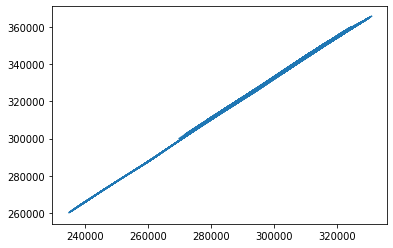

In [8]:
plt.plot(
    np.sum(DV_AIR, axis=2).reshape(-1), np.sum(air_subcol_l2_ch4, axis=2).reshape(-1)
)

### Sub-column of CH4,CO,H2O,O2

#### mixing ratio

In [9]:
# Aim: Match mrCH4 from US standard and XCH4 from TROPOMI L2 data
# Conclusion: there is a gap of XCH4 between US Standard and TROPOMI data

mrCH4 = np.transpose(np.genfromtxt(f"{aux_data_dir}/ch4.dat"))
mrH2O = np.transpose(np.genfromtxt(f"{aux_data_dir}/h2o.dat"))

kmtocm = 1e5
ch4_scale = 1.1029
h2o_scale = 1
altmrCH4 = mrCH4[1] * kmtocm
altmrH2O = mrH2O[1] * kmtocm
mixrateCH4 = mrCH4[0] * ch4_scale
mixrateH2O = mrH2O[0] * h2o_scale

# Interpolate and then sample using the altitude sample points determined from isobaric pressure increases
# mrCH4interp = np.interp(alt_level, altmrCH4, mixrateCH4)*1e9
# mrH2Ointerp = np.interp(alt_level, altmrH2O, mixrateH2O)*1e9

mrCH4interp = np.interp(alt_level, altmrCH4, mixrateCH4) * 1e9  # (ppb)
mrH2Ointerp = np.interp(alt_level, altmrH2O, mixrateH2O) * 1e9  # (ppb)

#### Absorption cross-section

#### Only for one point data

In [10]:
nominal_wavelength_l1_b7 = product_l1_b7.fetch(
    "band7_radiance/STANDARD_MODE/INSTRUMENT/nominal_wavelength"
)[0]
nominal_wavelength_l1_b8 = product_l1_b8.fetch(
    "band8_radiance/STANDARD_MODE/INSTRUMENT/nominal_wavelength"
)[0]

### Absorption optical thickness